In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split,
    learning_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.ensemble import (
    RandomForestRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib

In [4]:
df=pd.read_csv(
    "../data/processed/hyderabad_cleaned.csv"
)

In [6]:
X=df.drop(
    columns=['price','log_price']
)
y=df['log_price']

In [7]:
numerical_features=X.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features=X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
numeric_transformer=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy="median")
    ),
    (
        'scaler',
        StandardScaler()
    )
])

In [10]:
categorical_transformer=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [11]:
preprocessor=ColumnTransformer([
    (
        'num',
        numeric_transformer,
        numerical_features
    ),
    (
        'cat',
        categorical_transformer,
        categorical_features
    )
])

In [13]:
dt_pipeline=Pipeline([
    (
        'preprocessor',
        preprocessor
),
(
    'model',
    DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=10,
        random_state=42
    )
)])

In [14]:
rf_pipeline=Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            random_state=42,
            n_jobs=1
        )
    )
])

In [16]:
dt_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [17]:
rf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [18]:
def evaluate_model(model,X_test,y_test):
    preds=model.predict(X_test)
    rmse=np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )
    mae=mean_absolute_error(
        y_test,
        preds
    )
    r2=r2_score(
        y_test,
        preds
    )
    return {
        "RMSE":rmse,
        "MAE":mae,
        "R2":r2,
        "Prediction":preds
    }

In [19]:
dt_results=evaluate_model(
    dt_pipeline,
    X_test,
    y_test
)
dt_results

{'RMSE': np.float64(0.2347790249993665),
 'MAE': 0.15243004174597238,
 'R2': 0.8760636029256189,
 'Prediction': array([5.10606991, 4.39003946, 5.13197397, 3.9381783 , 5.84247293,
        4.19942413, 4.4558854 , 4.4558854 , 3.77421749, 4.52752515,
        3.70542268, 3.81800287, 4.81909182, 5.33281523, 4.15681865,
        4.69652443, 4.69652443, 3.68887945, 4.72922237, 4.52752515,
        4.19942413, 5.82995253, 3.96371582, 3.63978711, 4.39003946,
        4.69652443, 5.10606991, 5.51906056, 3.96371582, 4.52752515,
        4.37255102, 4.69652443, 4.24021669, 4.66343909, 4.69652443,
        4.39003946, 3.81800287, 4.69652443, 4.1672478 , 3.6505739 ,
        3.9381783 , 4.03768671, 3.72107455, 3.77421749, 5.97569148,
        4.39003946, 3.81800287, 3.77421749, 3.81800287, 3.72107455,
        4.10466104, 3.52088291, 3.9381783 , 3.78418963, 3.1191907 ,
        4.15681865, 3.72107455, 4.4558854 , 4.69652443, 4.14789617,
        4.03768671, 4.52672139, 4.45058421, 3.94260795, 5.33281523,
     

In [20]:
rf_results=evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)
rf_results

{'RMSE': np.float64(0.1885961984127515),
 'MAE': 0.11314060724092108,
 'R2': 0.9200264921305581,
 'Prediction': array([5.00073389, 4.41335549, 5.22725673, 3.85162651, 5.89256074,
        4.20034652, 4.56174585, 4.52266704, 3.84765251, 4.5204679 ,
        3.91505454, 3.84829285, 4.82684484, 5.84684209, 4.37793939,
        4.71734792, 4.71376549, 3.72449247, 4.80030627, 4.45848526,
        4.20034652, 5.75586751, 3.91962486, 3.69445747, 4.27854632,
        4.70343234, 5.06799906, 5.5066066 , 3.95474906, 4.54269269,
        4.35574466, 4.62072219, 4.34404146, 4.67717564, 4.6888136 ,
        4.37916247, 3.89864977, 4.70268039, 4.25918189, 3.84978378,
        3.89410817, 4.04667937, 3.66329497, 3.78225546, 6.01371456,
        4.41335549, 3.77507404, 3.81472491, 3.84692703, 3.65890944,
        4.07781162, 3.43125484, 3.95802686, 3.72122872, 3.31151088,
        4.27605508, 3.66451431, 4.48507714, 4.76708176, 4.07098636,
        4.1364446 , 4.60942739, 4.44668356, 3.87285919, 5.52754152,
     

In [21]:
results_df=pd.DataFrame({
    'Model':[
        'Decision Tree',
        'Random Forest'
    ],
    'RMSE':[
        dt_results['RMSE'],
        rf_results['RMSE']
    ],
    'MAE':[
        dt_results['MAE'],
        rf_results['MAE']
    ],
    'R2':[
        dt_results['R2'],
        rf_results['R2']
    ]
})
results_df

,Model,RMSE,MAE,R2
0,Decision Tree,0.234779,0.152430,0.876064
1,Random Forest,0.188596,0.113141,0.920026


In [22]:
results_df.to_csv(
    "../reports/tree_model_results.csv",
    index=False
)

In [24]:
rf_model=rf_pipeline.named_steps['model']

In [25]:
encoded_features=list(
    rf_pipeline.named_steps[
        'preprocessor'
        ]
        .named_transformers_[
            'cat'
        ]
        .named_steps[
            'encoder'
        ]
        .get_feature_names_out(
            categorical_features
        )
)

In [26]:
all_features=(
    numerical_features +
    encoded_features
)

In [27]:
importance_df=pd.DataFrame({
    "Feature":all_features,
    "Importance":rf_model.feature_importances_
})

In [28]:
top_featuires=importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

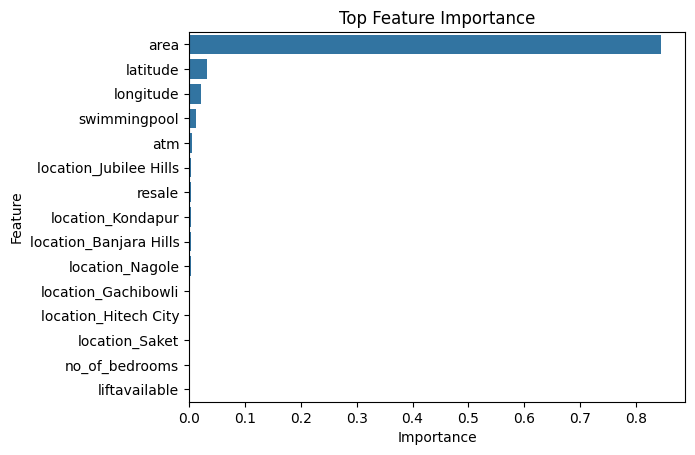

In [31]:
plt.Figure(figsize=(10,6))
sns.barplot(
    data=top_featuires,
    x='Importance',
    y="Feature"
)
plt.title("Top Feature Importance")
plt.savefig(
    "../images/feature_importance.png",
    bbox_inches='tight'
)
plt.show()

In [ ]:
train_sizes,train_scores,validation_scores=learning_curve(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)